# Sales Forecasting & Demand Analysis
## Project Objective
the objective of this project is to analyze historical Walmart sales data, identify demand patterns, understand the impact of holidays and store charcteristics, and forecast future weekly sales using time series modeling.

Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load all Datasets

In [3]:
train = pd.read_csv("C:/Users/akash/OneDrive/Desktop/AKASH BHAI FILE/Projects/Sales Forecasting/data/train.csv")
features = pd.read_csv("C:/Users/akash/OneDrive/Desktop/AKASH BHAI FILE/Projects/Sales Forecasting/data/features.csv")
stores = pd.read_csv("C:/Users/akash/OneDrive/Desktop/AKASH BHAI FILE/Projects/Sales Forecasting/data/stores.csv")

In [5]:
train.head()
features.head()
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


## Initial Obserations
- The train dataset contains historical weekly sales by store and department.
- Feature dataset includes external business factor such as temperature, fuel price, CPI, and unemployment.
- Store dataset provides store type and size information.
- The data is split across multiple files, which reflects a realistic business data pipeline.

Merge datasets

In [6]:
# first merge train+features
df = train.merge(features, on = ["Store", "Date", "IsHoliday"], how = "left")

In [7]:
# Then merging stores
df = df.merge(stores, on="Store", how="left")

In [8]:
df.shape

(421570, 16)

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
# Creating extra time features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week

EDA

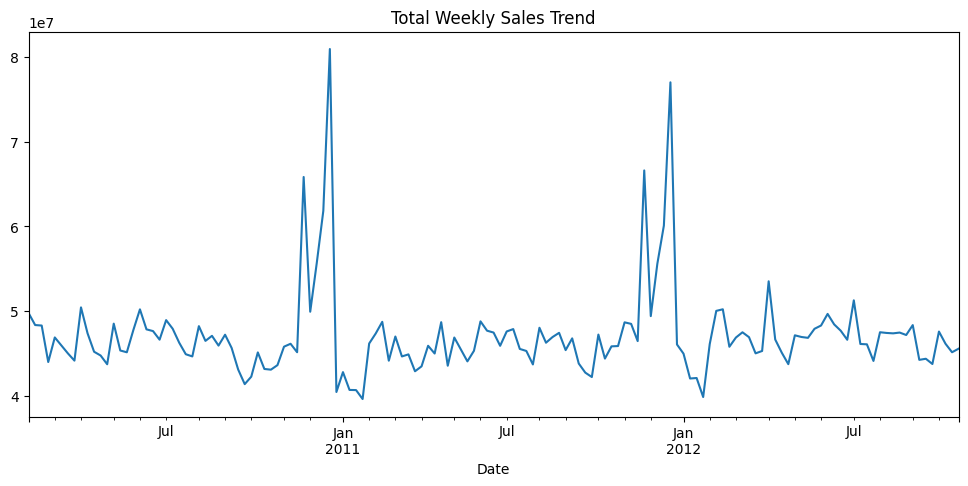

In [11]:
# Total sales trend
sales_trend = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(12,5))
sales_trend.plot()
plt.title("Total Weekly Sales Trend")
plt.show()

## Sales Trend Insight
- Weekly sales show strong fluctuations over time.
- Several sharp spikes are visible, indicating seasonal or holidays-driven demand.
- Overall sales remain fairly stable with recurring demand peaks.

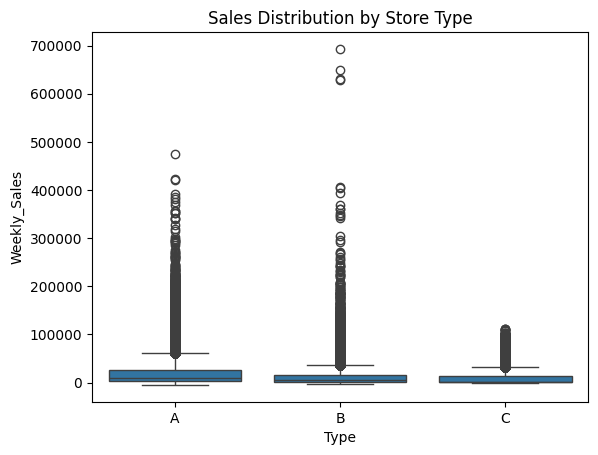

In [12]:
# Sales by store type
sns.boxplot(x="Type", y = "Weekly_Sales", data = df)
plt.title("Sales Distribution by Store Type")
plt.show()

## Store Type Insight
- Sales patterns vary across store types.
- Store performance is influenced by both store category and internal demand variation.

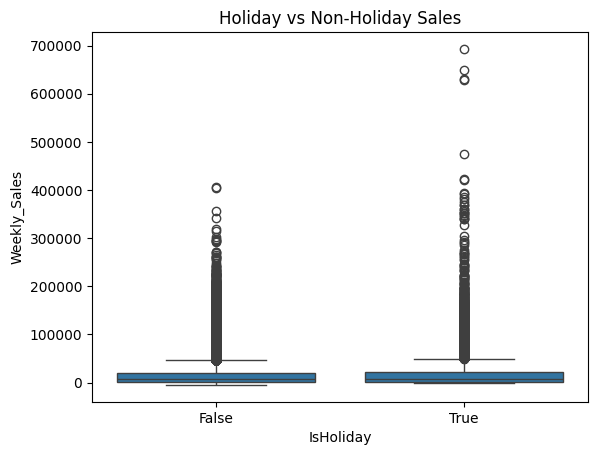

In [13]:
# Holiday vs non-holiday sales
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=df)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

## Holiday Impact Insight
- Holiday periods show stronger sales activity compared to regular weeks.
- This suggest that holiday are important derviers of revenue and demand planning

Aggregate Monthly Sales

In [14]:
monthly_sales = df.groupby(["Year", "Month"])["Weekly_Sales"].sum().reset_index()

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" + monthly_sales["Month"].astype(str)
)

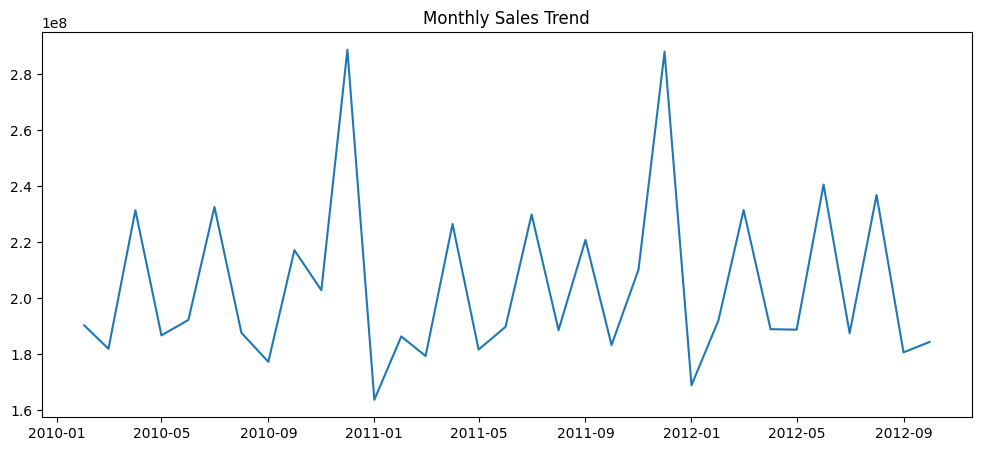

In [15]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Date"], monthly_sales["Weekly_Sales"])
plt.title("Monthly Sales Trend")
plt.show()

Prepare Time Series Data

In [16]:
sales_ts = df.groupby("Date")["Weekly_Sales"].sum().reset_index()
sales_ts.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [17]:
sales_ts.set_index("Date", inplace=True)

In [18]:
sales_ts.head()

,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


Ploting the Time Series

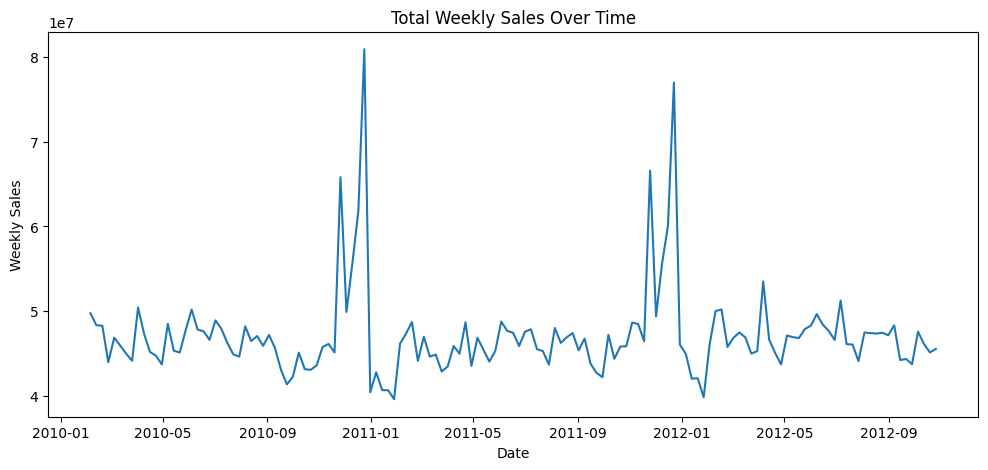

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(sales_ts.index, sales_ts["Weekly_Sales"])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

Moving Average Trend

In [20]:
sales_ts["MA_4"] = sales_ts["Weekly_Sales"].rolling(window=4).mean()
sales_ts["MA_12"] = sales_ts["Weekly_Sales"].rolling(window=12).mean()

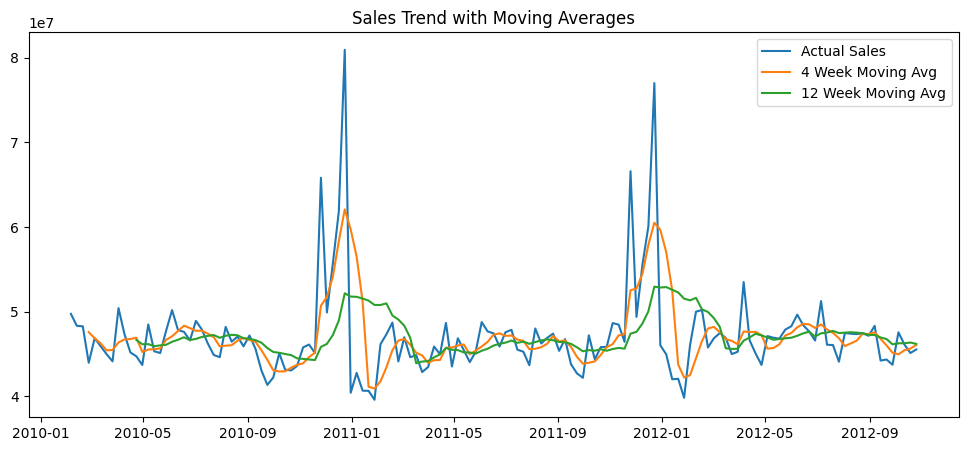

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(sales_ts["Weekly_Sales"], label = "Actual Sales")
plt.plot(sales_ts["MA_4"], label = "4 Week Moving Avg")
plt.plot(sales_ts["MA_12"], label= "12 Week Moving Avg")
plt.legend()
plt.title("Sales Trend with Moving Averages")
plt.show()

- Insight: Sales falctuate weekly but show seasonal patterns and overall stability When smoothed with moving averages.


Train a Forecasting Model

In [25]:
# We will use Facebook Prophet, which is very popular in business forecasting.
# pip install prophet
from prophet import Prophet

In [26]:
prophet_df = sales_ts.reset_index()

prophet_df = prophet_df.rename(columns={"Date": "ds",
                                        "Weekly_Sales": "y"
                                        })
prophet_df = prophet_df[["ds", "y"]]

In [27]:
prophet_df.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


Train the Forecast Model

In [28]:
model = Prophet()

model.fit(prophet_df)

20:48:18 - cmdstanpy - INFO - Chain [1] start processing
20:48:18 - cmdstanpy - INFO - Chain [1] done processing


Forecast Future Sales

In [29]:
future = model.make_future_dataframe(periods=12, freq="W")

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-02-05,4.703757e+07,4.341768e+07,5.226697e+07,4.703757e+07,4.703757e+07,7.134521e+05,7.134521e+05,7.134521e+05,7.134521e+05,7.134521e+05,7.134521e+05,0.0,0.0,0.0,4.775102e+07
1,2010-02-12,4.703881e+07,4.396782e+07,5.275122e+07,4.703881e+07,4.703881e+07,1.431913e+06,1.431913e+06,1.431913e+06,1.431913e+06,1.431913e+06,1.431913e+06,0.0,0.0,0.0,4.847072e+07
2,2010-02-19,4.704005e+07,4.280390e+07,5.181459e+07,4.704005e+07,4.704005e+07,5.278070e+04,5.278070e+04,5.278070e+04,5.278070e+04,5.278070e+04,5.278070e+04,0.0,0.0,0.0,4.709283e+07
3,2010-02-26,4.704129e+07,4.122799e+07,5.032233e+07,4.704129e+07,4.704129e+07,-1.164517e+06,-1.164517e+06,-1.164517e+06,-1.164517e+06,-1.164517e+06,-1.164517e+06,0.0,0.0,0.0,4.587677e+07
4,2010-03-05,4.704253e+07,4.132882e+07,4.991135e+07,4.704253e+07,4.704253e+07,-1.439871e+06,-1.439871e+06,-1.439871e+06,-1.439871e+06,-1.439871e+06,-1.439871e+06,0.0,0.0,0.0,4.560266e+07


Plot Forecast

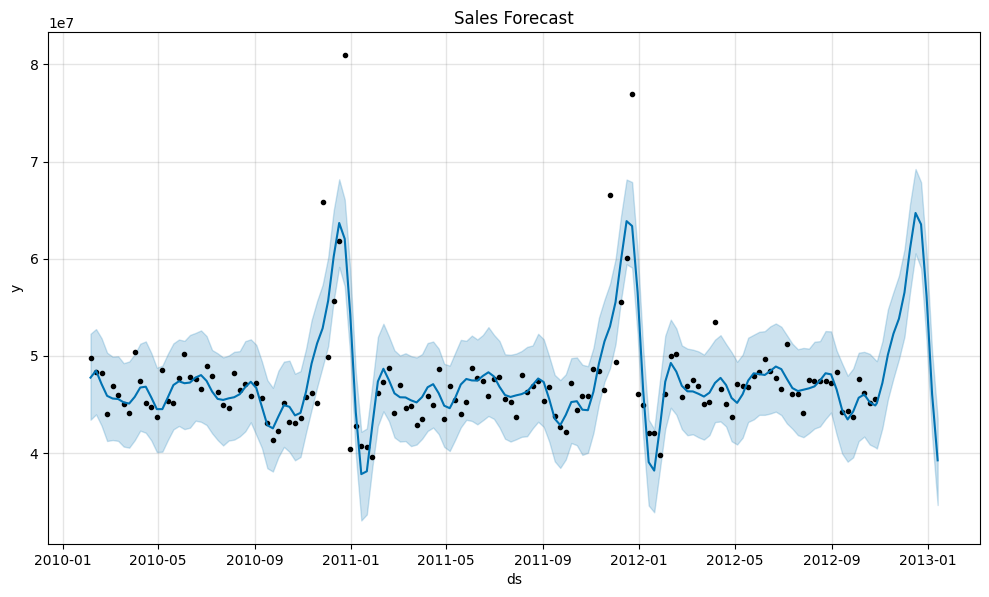

In [30]:
model.plot(forecast)
plt.title("Sales Forecast")
plt.show()

## Forecast Component Insight
- The component plots highlight trend and seasonality patterns.
- Seasonal cycles play a major role in explaining changes in weekly sales.

Prophet Components

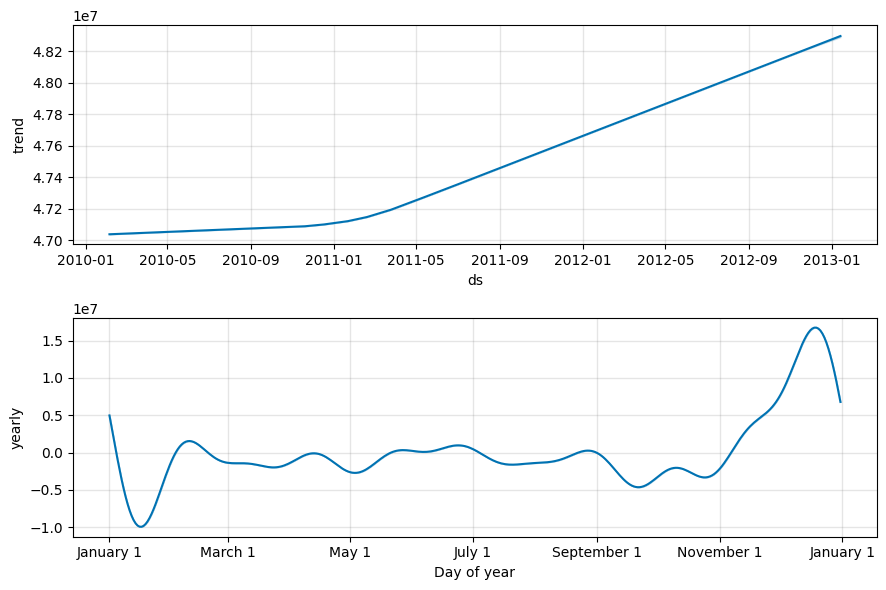

In [31]:
model.plot_components(forecast)
plt.show()

# Final Conclusion

This project combined historical sales, feature and store data to analyze retail demand and forecast future sales.

### Key Findings
- Weekly sales show strong seasonal fluctuations.
- Holiday periods lead to noticeable spikes in sales.
- Store performance varies by store type.
- Moving averages help reval the long-term trend bhind volatile weekly sales.
- Prophet forecasting successfully captured future demands pattern and recurring seasonality.

### Business Recommendations
- Increase inventory planning before holiday periods.
- Monitor high-performing store types more closely for capacity planning.
- Use forecasted demand to optimize staffing, stock allocation, and promotional timing.